# Classificação de tumores com uma rede neural em Keras

**Disciplina:** Matemática para Ciência de Dados  
**Integrante:** Bruno Aparecido Barbosa  
**Data:** 26/09/2026

## Objetivo

Neste trabalho desenvolvemos uma rede neural para classificar tumores de mama como malignos ou benignos. Partimos da organização geral do arquivo `exemplo4.py`, mas alteramos a base de dados, a quantidade de neurônios, o número de camadas, as funções de ativação, a função de perda e o otimizador.

A base Breast Cancer Wisconsin foi escolhida por ser um problema real de classificação binária e por já estar disponível no `scikit-learn`. O trabalho é apenas educacional e não deve ser utilizado para diagnóstico ou qualquer decisão médica.

## 1. Bibliotecas e reprodutibilidade

Definimos uma semente aleatória para reduzir variações entre execuções. O Keras será usado com o backend PyTorch, configurado antes da importação da biblioteca.

In [1]:
import os
import random

os.environ["KERAS_BACKEND"] = "torch"

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEMENTE = 42
random.seed(SEMENTE)
np.random.seed(SEMENTE)
keras.utils.set_random_seed(SEMENTE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 8)

## 2. Carregamento e entendimento da base

Cada linha representa uma amostra e contém 30 medidas calculadas a partir de imagens digitalizadas de células. A variável-alvo possui duas classes:

- `0`: tumor maligno;
- `1`: tumor benigno.

No modelo, a saída sigmoide será interpretada como a probabilidade estimada da classe `1`, ou seja, de a amostra ser benigna.

In [2]:
dados = load_breast_cancer(as_frame=True)
X = dados.data
y = dados.target

print(f"Quantidade de amostras: {X.shape[0]}")
print(f"Quantidade de atributos: {X.shape[1]}")
print(f"Valores ausentes: {X.isna().sum().sum()}")

display(X.head())

Quantidade de amostras: 569
Quantidade de atributos: 30
Valores ausentes: 0


,mean radius,mean texture,mean perimeter,mean area,...,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,...,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,...,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,...,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,...,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,...,0.4000,0.1625,0.2364,0.07678


,quantidade
target,
Maligno,212
Benigno,357


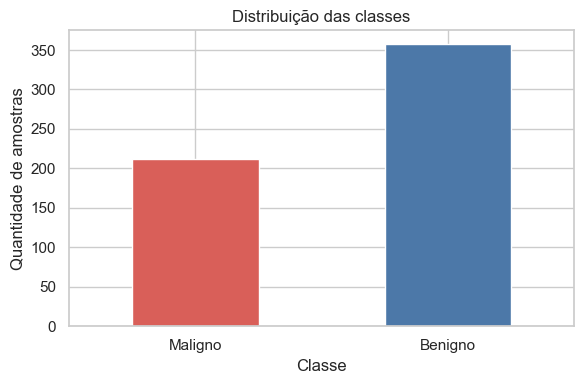

In [3]:
distribuicao = (
    y.value_counts()
    .sort_index()
    .rename(index={0: "Maligno", 1: "Benigno"})
    .rename("quantidade")
)

display(distribuicao.to_frame())

ax = distribuicao.plot(
    kind="bar",
    color=["#d95f59", "#4c78a8"],
    rot=0,
    figsize=(6, 4),
)
ax.set_title("Distribuição das classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de amostras")
plt.tight_layout()
plt.show()

## 3. Separação e padronização dos dados

Primeiro separamos 20% da base para o teste final. Em seguida, reservamos 20% dos dados restantes para validação. Usamos `stratify` nas duas divisões para manter aproximadamente a mesma proporção das classes.

A padronização é necessária porque os 30 atributos possuem escalas diferentes. O `StandardScaler` é ajustado **somente** no conjunto de treinamento. Validação e teste recebem a mesma transformação, sem fornecer informações futuras ao treinamento.

In [4]:
X_treino_completo, X_teste, y_treino_completo, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMENTE,
    stratify=y,
)

X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_treino_completo,
    y_treino_completo,
    test_size=0.20,
    random_state=SEMENTE,
    stratify=y_treino_completo,
)

padronizador = StandardScaler()
X_treino_pad = padronizador.fit_transform(X_treino)
X_validacao_pad = padronizador.transform(X_validacao)
X_teste_pad = padronizador.transform(X_teste)

print(f"Treino: {len(X_treino)} amostras")
print(f"Validação: {len(X_validacao)} amostras")
print(f"Teste: {len(X_teste)} amostras")

Treino: 364 amostras
Validação: 91 amostras
Teste: 114 amostras


## 4. Arquitetura escolhida

A rede possui 30 entradas, uma para cada atributo. A primeira camada oculta tem 16 neurônios e a segunda tem 8, ambas com ativação ReLU. A saída contém um neurônio com sigmoide.

A ReLU foi usada nas camadas ocultas por ser simples e eficiente. A sigmoide limita a saída ao intervalo entre 0 e 1, o que permite interpretá-la como uma probabilidade em um problema binário.

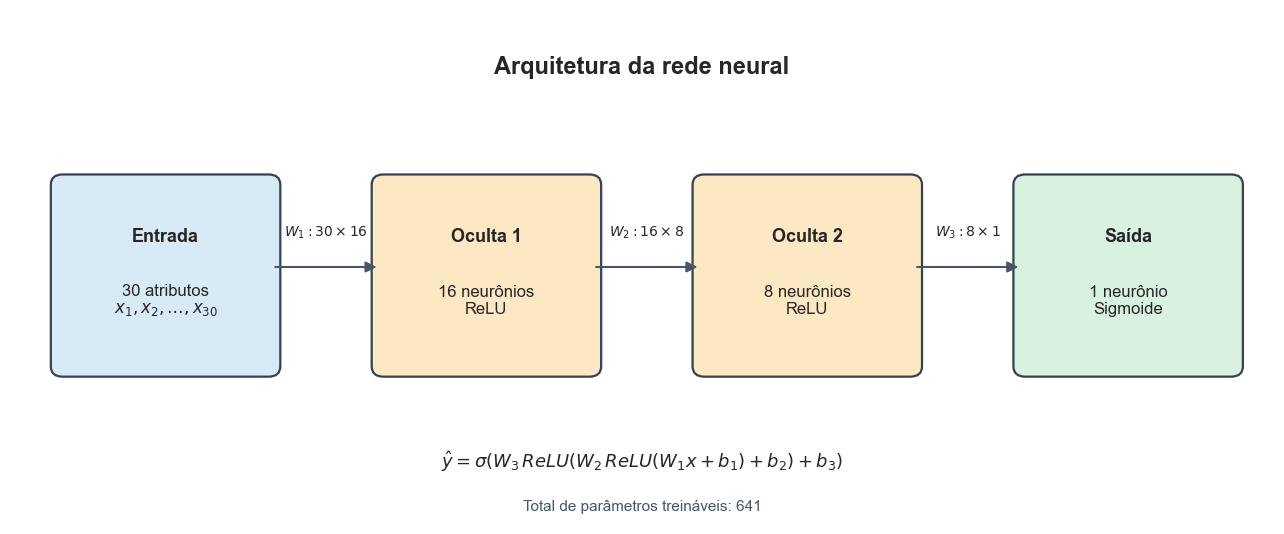

In [5]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def desenhar_arquitetura(caminho="arquitetura_rede.png"):
    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.set_xlim(0, 13)
    ax.set_ylim(0, 6)
    ax.axis("off")

    camadas = [
        (0.5, 1.8, 2.2, 2.2, "Entrada", "30 atributos\n$x_1, x_2, …, x_{30}$", "#d9eaf7"),
        (3.8, 1.8, 2.2, 2.2, "Oculta 1", "16 neurônios\nReLU", "#fce8c3"),
        (7.1, 1.8, 2.2, 2.2, "Oculta 2", "8 neurônios\nReLU", "#fce8c3"),
        (10.4, 1.8, 2.2, 2.2, "Saída", "1 neurônio\nSigmoide", "#d9f2df"),
    ]

    for x, y0, largura, altura, titulo, detalhe, cor in camadas:
        caixa = FancyBboxPatch(
            (x, y0),
            largura,
            altura,
            boxstyle="round,pad=0.08,rounding_size=0.12",
            facecolor=cor,
            edgecolor="#334155",
            linewidth=1.6,
        )
        ax.add_patch(caixa)
        ax.text(x + largura / 2, y0 + 1.55, titulo, ha="center", va="center", fontsize=13, weight="bold")
        ax.text(x + largura / 2, y0 + 0.8, detalhe, ha="center", va="center", fontsize=12)

    ligacoes = [
        (2.7, 3.0, 3.8, 3.0, "$W_1: 30 \\times 16$"),
        (6.0, 3.0, 7.1, 3.0, "$W_2: 16 \\times 8$"),
        (9.3, 3.0, 10.4, 3.0, "$W_3: 8 \\times 1$"),
    ]

    for x1, y1, x2, y2, rotulo in ligacoes:
        seta = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=1.5,
            color="#475569",
        )
        ax.add_patch(seta)
        ax.text((x1 + x2) / 2, y1 + 0.35, rotulo, ha="center", fontsize=10)

    ax.text(6.5, 5.25, "Arquitetura da rede neural", ha="center", fontsize=17, weight="bold")
    ax.text(
        6.5,
        0.65,
        r"$\hat{y}=\sigma\left(W_3\,ReLU\left(W_2\,ReLU\left(W_1x+b_1\right)+b_2\right)+b_3\right)$",
        ha="center",
        fontsize=13,
    )
    ax.text(6.5, 0.15, "Total de parâmetros treináveis: 641", ha="center", fontsize=11, color="#475569")

    plt.tight_layout()
    plt.savefig(caminho, dpi=180, bbox_inches="tight")
    plt.show()


desenhar_arquitetura()

### Quantidade de parâmetros

- Primeira camada: $(30 \times 16) + 16 = 496$ parâmetros;
- Segunda camada: $(16 \times 8) + 8 = 136$ parâmetros;
- Camada de saída: $(8 \times 1) + 1 = 9$ parâmetros;
- Total: $496 + 136 + 9 = 641$ parâmetros treináveis.

Cada soma inclui os pesos e os vieses da camada.

## 5. Construção do modelo em Keras

Utilizamos `binary_crossentropy`, apropriada para classificação binária, e o otimizador Adam com taxa de aprendizado de 0,001. A acurácia foi escolhida como métrica principal para acompanhar o treinamento.

In [6]:
modelo = keras.Sequential(
    [
        keras.layers.Input(shape=(X_treino_pad.shape[1],), name="atributos"),
        keras.layers.Dense(16, activation="relu", name="camada_oculta_1"),
        keras.layers.Dense(8, activation="relu", name="camada_oculta_2"),
        keras.layers.Dense(1, activation="sigmoid", name="saida"),
    ],
    name="rede_cancer_mama",
)

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

modelo.summary()

Model: "rede_cancer_mama"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ camada_oculta_1 (Dense)         │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ camada_oculta_2 (Dense)         │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Treinamento em mini-batches

Escolhemos `batch_size=16`. Isso significa que o modelo processa 16 amostras, calcula a média dos gradientes desse grupo e então atualiza os pesos. Uma época termina quando todas as amostras de treino foram utilizadas.

A parada antecipada acompanha a perda de validação. Caso ela não melhore por 12 épocas, o treinamento é interrompido e os melhores pesos são restaurados. Assim evitamos continuar ajustando a rede quando ela já deixou de melhorar fora dos dados de treino.

In [7]:
TAMANHO_BATCH = 16
atualizacoes_por_epoca = int(np.ceil(len(X_treino_pad) / TAMANHO_BATCH))
print(f"Atualizações de pesos por época: {atualizacoes_por_epoca}")

parada_antecipada = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
)

historico = modelo.fit(
    X_treino_pad,
    y_treino,
    validation_data=(X_validacao_pad, y_validacao),
    epochs=100,
    batch_size=TAMANHO_BATCH,
    callbacks=[parada_antecipada],
    verbose=0,
)

print(f"Épocas executadas: {len(historico.history['loss'])}")

Atualizações de pesos por época: 23


Épocas executadas: 32


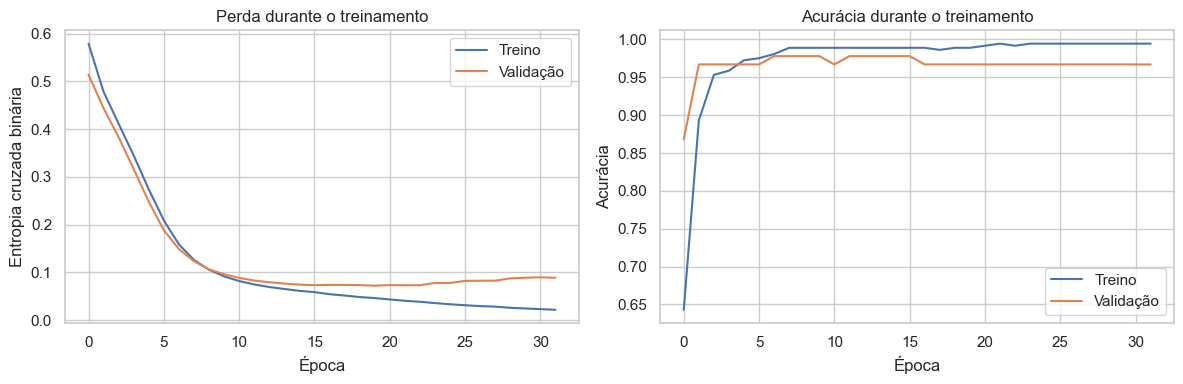

In [8]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

eixos[0].plot(historico.history["loss"], label="Treino")
eixos[0].plot(historico.history["val_loss"], label="Validação")
eixos[0].set_title("Perda durante o treinamento")
eixos[0].set_xlabel("Época")
eixos[0].set_ylabel("Entropia cruzada binária")
eixos[0].legend()

eixos[1].plot(historico.history["accuracy"], label="Treino")
eixos[1].plot(historico.history["val_accuracy"], label="Validação")
eixos[1].set_title("Acurácia durante o treinamento")
eixos[1].set_xlabel("Época")
eixos[1].set_ylabel("Acurácia")
eixos[1].legend()

plt.tight_layout()
plt.savefig("historico_treinamento.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Avaliação no conjunto de teste

O conjunto de teste permaneceu separado até este momento. Transformamos as probabilidades em classes usando o limiar 0,5: valores a partir de 0,5 são classificados como benignos (`1`); os demais, como malignos (`0`).

In [9]:
perda_teste, acuracia_teste = modelo.evaluate(X_teste_pad, y_teste, verbose=0)
probabilidades = modelo.predict(X_teste_pad, verbose=0).ravel()
previsoes = (probabilidades >= 0.5).astype(int)

print(f"Perda no teste: {perda_teste:.4f}")
print(f"Acurácia no teste: {acuracia_teste:.2%}")

Perda no teste: 0.0958
Acurácia no teste: 94.74%


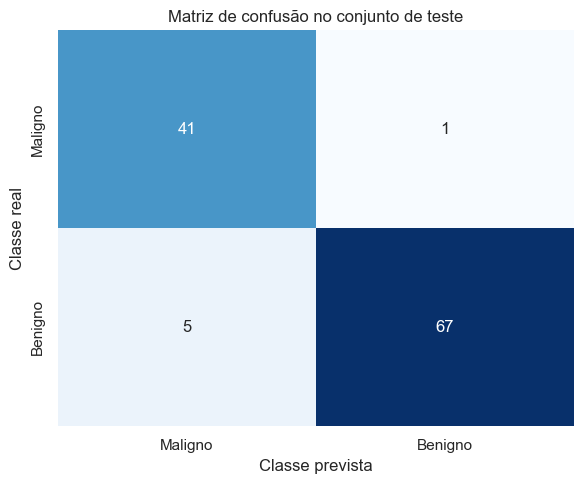

In [10]:
matriz = confusion_matrix(y_teste, previsoes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Maligno", "Benigno"],
    yticklabels=["Maligno", "Benigno"],
)
plt.title("Matriz de confusão no conjunto de teste")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.savefig("matriz_confusao.png", dpi=180, bbox_inches="tight")
plt.show()

In [11]:
relatorio = classification_report(
    y_teste,
    previsoes,
    target_names=["Maligno", "Benigno"],
    output_dict=True,
)

relatorio_df = pd.DataFrame(relatorio).T
display(relatorio_df.round(3))

,precision,recall,f1-score,support
Maligno,0.891,0.976,0.932,42.000
Benigno,0.985,0.931,0.957,72.000
accuracy,0.947,0.947,0.947,0.947
macro avg,0.938,0.953,0.944,114.000
weighted avg,0.951,0.947,0.948,114.000


## 8. Resultado resumido

A célula abaixo produz uma conclusão usando os resultados da própria execução. Dessa forma, o texto permanece consistente mesmo se o notebook for treinado novamente em outro computador.

In [12]:
acertos = accuracy_score(y_teste, previsoes)
erros = int((previsoes != y_teste.to_numpy()).sum())

display(
    Markdown(
        f'''\
No conjunto de teste, a rede alcançou **{acertos:.2%} de acurácia** e classificou
corretamente **{len(y_teste) - erros} das {len(y_teste)} amostras**. A matriz de confusão
permite observar separadamente os acertos e erros para tumores malignos e benignos.
'''
    )
)

No conjunto de teste, a rede alcançou **94.74% de acurácia** e classificou
corretamente **108 das 114 amostras**. A matriz de confusão
permite observar separadamente os acertos e erros para tumores malignos e benignos.


## 9. Relação com o exemplo da aula

| Elemento | `exemplo4.py` | Este trabalho |
|---|---|---|
| Base | Duas luas sintéticas | Breast Cancer Wisconsin |
| Entradas | 2 | 30 |
| Camadas ocultas | 2 camadas com 5 neurônios no Keras | 16 e 8 neurônios |
| Ativações ocultas | ReLU e tanh | ReLU e ReLU |
| Saída | Sigmoide | Sigmoide |
| Otimizador | SGD | Adam |
| Perda | Erro quadrático médio | Entropia cruzada binária |
| Avaliação | Mesmos dados do treino | Treino, validação e teste separados |

## 10. Conclusão e limitações

Conseguimos adaptar a rede do exemplo para um conjunto com mais atributos e dados reais. A padronização, a validação separada e a parada antecipada deixaram o processo de treinamento mais controlado. A arquitetura permaneceu pequena, com 641 parâmetros, o que é adequado para uma base de apenas 569 amostras.

Como limitações, a base é relativamente pequena e já vem tratada. Além disso, bons resultados neste conjunto não garantem que o modelo funcione da mesma maneira com dados coletados em outros contextos. Para trabalhos futuros, poderíamos repetir o treinamento com diferentes sementes ou testar outras quantidades de neurônios, mantendo o conjunto de teste separado.